# Part 2 - Copula-Based Dependence Modelling

Part 1 extracted, for each of the five assets, the risk-neutral marginal distribution $F_k$ implied by the options market. However, knowing each asset's individual distribution says nothing about how the assets move together. To price a basket option we need to simulate all five assets jointly, which requires specifying a dependence structure.  

We use a copula to model this dependece. By Sklar's theorem, any joint distribution can be decomposed as  $$F_{1,...,5}​(x_1​,...,x_5​)=C(F_1​(x_1​),...,F_5​(x_5​))$$ where $ C : [0,1]^5 \to [0,1]$ is the copula: a joint distribution on uniform random variables that encodes only the dependece, completely separated from the marginals. This separation allows us to pair the realistic, market-implied marginals from Part 1 with any dependence structure we choose to assume. 

As a first choice of dependence structure, we implement the Gaussian copula, which assumes that the dependence between assets follows the same structure as a multivariate normal distribution with correlation matrix $R$.

To estimate R, we download one year of daily adjusted closing prices for the five assets.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copula import estimate_correlation, build_inverse_cdf, sample_gaussian_copula

tickers = ["NVDA", "PLTR", "MSFT", "STX", "GOOGL"]
df = pd.read_csv("marginal_dist.csv")

The heatmap below displays the pairwise correlations between the five assets, with values annotated for clarity.


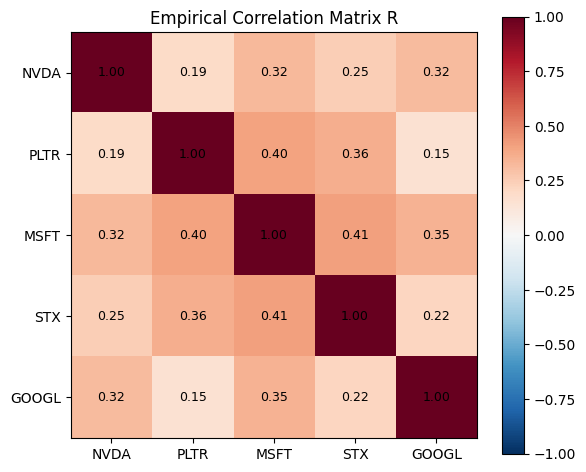

In [3]:
R = estimate_correlation(tickers)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(R, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(tickers))); ax.set_xticklabels(tickers)
ax.set_yticks(range(len(tickers))); ax.set_yticklabels(tickers)
plt.colorbar(im, ax=ax)
ax.set_title("Empirical Correlation Matrix R")
for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, f"{R[i,j]:.2f}", ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.show()

Before sampling from the copula, we build the inverse CDF $F_k^{-1}$ for each asset by interpolating the discrete $(K, \text{cdf})$ table produced in Part 1. This allows us to map any uniform sample $U_k \in [0,1]$ back to an asset price $S_k = F_k^{-1}(U_k)$

In [4]:
inv_cdfs = []
for ticker in tickers:
    asset = df[df["ticker"] == ticker]
    K_grid = asset["K"].values
    cdf    = asset["cdf"].values
    inv_cdfs.append(build_inverse_cdf(K_grid, cdf))

We now sample $n_{sim} = 10{,}000$ joint outcomes from the Gaussian copula. Following the algorithm from Choi (2026, M9): 
- we generate independent standard normals
- correlate them via Cholesky decomposition of $R$, 
- transform to uniforms $U_k = N(Z'_k)$, 
- and finally recover asset prices via $S_k = F_k^{-1}(U_k)$.

In [5]:
n_sim = 10_000
S, U = sample_gaussian_copula(R, inv_cdfs, n_sim)

We validate the dependence structure by plotting the uniform copula samples $U_i$ against $U_j$ for five representative pairs of assets. Under the Gaussian copula, these scatter plots should show an elliptical dependence structure: concentrated along the diagonal for highly correlated pairs, and more spread out for less correlated ones. Crucially, the corners of each plot should be relatively empty, reflecting the absence of tail dependence in the Gaussian copula.

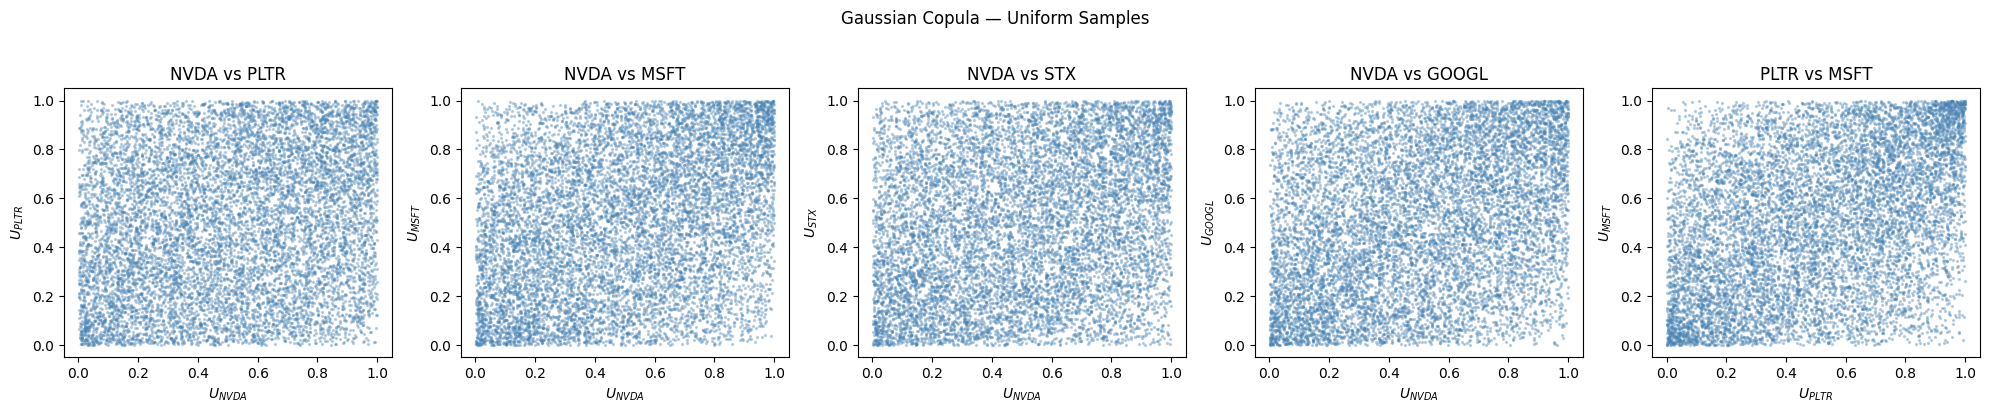

In [6]:
pairs = [(0,1), (0,2), (0,3), (0,4), (1,2)]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(U[:, i], U[:, j], s=2, alpha=0.3, color="steelblue")
    ax.set_xlabel(f"$U_{{{tickers[i]}}}$")
    ax.set_ylabel(f"$U_{{{tickers[j]}}}$")
    ax.set_title(f"{tickers[i]} vs {tickers[j]}")
plt.suptitle("Gaussian Copula — Uniform Samples", y=1.02)
plt.tight_layout()
plt.show()


Finally, we verify that the marginal distributions are correctly preserved. For each asset, we overlay the histogram of simulated terminal prices against the risk-neutral density extracted in Part 1. If the copula implementation is correct, the two should match closely, confirming that the Gaussian copula has introduced dependence between assets without distorting their individual distributions.

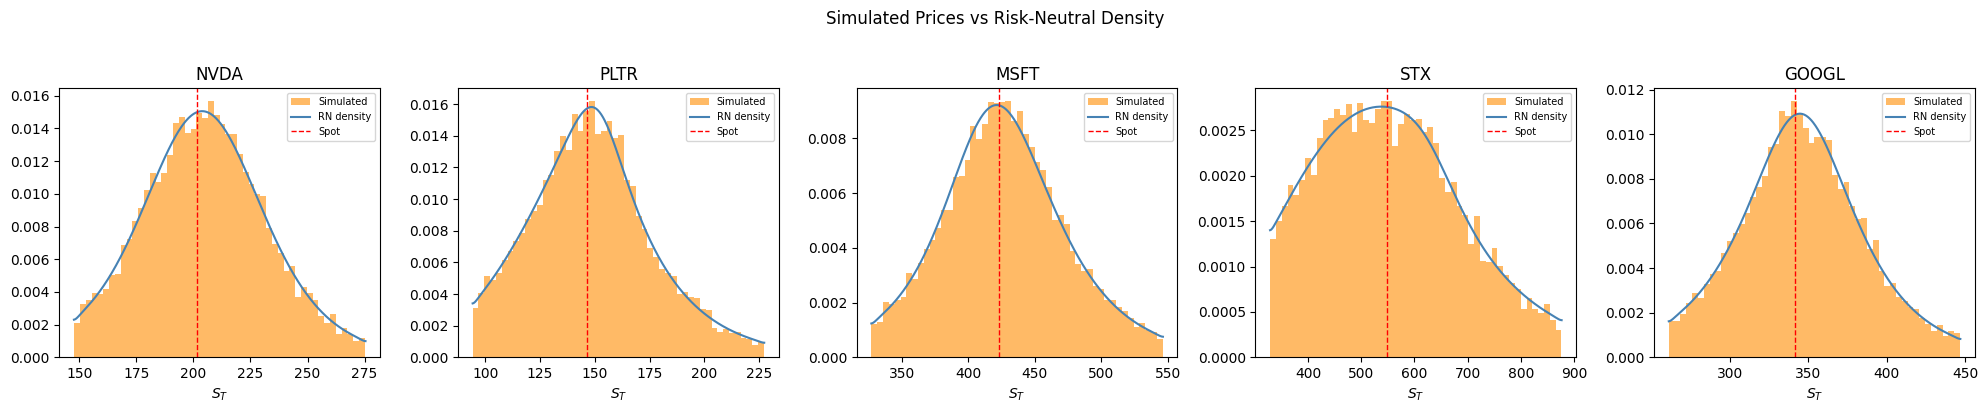

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ticker in enumerate(tickers):
    asset = df[df["ticker"] == ticker]
    axes[i].hist(S[:, i], bins=50, density=True,
                 color="darkorange", alpha=0.6, label="Simulated")
    axes[i].plot(asset["K"].values, asset["pdf"].values,
                 color="steelblue", lw=1.5, label="RN density")
    axes[i].axvline(asset["S"].iloc[0], color="red", lw=1,
                    linestyle="--", label="Spot")
    axes[i].set_title(f"{ticker}")
    axes[i].set_xlabel("$S_T$")
    axes[i].legend(fontsize=7)
plt.suptitle("Simulated Prices vs Risk-Neutral Density", y=1.02)
plt.tight_layout()
plt.show()

While the Gaussian copula provides a simple and tractable way to model dependence, it has a well-known limitation: it implies no tail dependence. This means that in the Gaussian copula framework, extreme co-movements become asymptotically independent. This is an unrealistic assumption for equity markets, where joint crashes are well-documented empirically.

To address this, we implement the Student-t copula, which introduces tail dependence by borrowing its dependence structure from a multivariate Student-t distribution with $\nu$
degrees of freedom. The key difference from the Gaussian copula is the introduction of a shared random variable $V \sim \chi^2(\nu)$ that scales all assets simultaneously, creating the possibility of joint extreme events. 

The parameter $\nu$ controls the strength of this tail dependence: smaller values of $\nu$ imply heavier tails and stronger co-movements in the extremes, while as $\nu \to \infty$ the Student-t copula converges to the Gaussian copula.

To select $\nu$, we estimate it from historical data by maximum likelihood. We first transform the historical log-returns of each asset into pseudo-observations, their empirical ranks scaled to $[0,1]$, which isolates the dependence structure from the marginals. We then maximize the log-likelihood of the Student-t copula over $\nu$, using the correlation matrix $R$ already estimated in the Gaussian copula step.

In [8]:
from copula import estimate_nu, sample_student_copula

We first estimate the degrees of freedom parameter nu by maximum likelihood. The value of nu directly controls the strength of tail dependence. We print it to interpret how heavy-tailed the estimated dependence structure is.

In [9]:
nu = estimate_nu(tickers, R)
print(f"Estimated degrees of freedom: nu = {nu:.2f}")

Estimated degrees of freedom: nu = 9.72


We now sample 10,000 joint outcomes from the Student-t copula using the estimated nu and the same correlation matrix R from the Gaussian copula step.


In [10]:
S_t, U_t = sample_student_copula(R, nu, inv_cdfs, n_sim)

We validate the dependence structure by plotting the uniform copula samples for the same five pairs as before. Compared to the Gaussian copula, the Student-t scatter plots should show points more concentrated in the corners, reflecting the tail dependence introduced by the shared chi-squared variable.


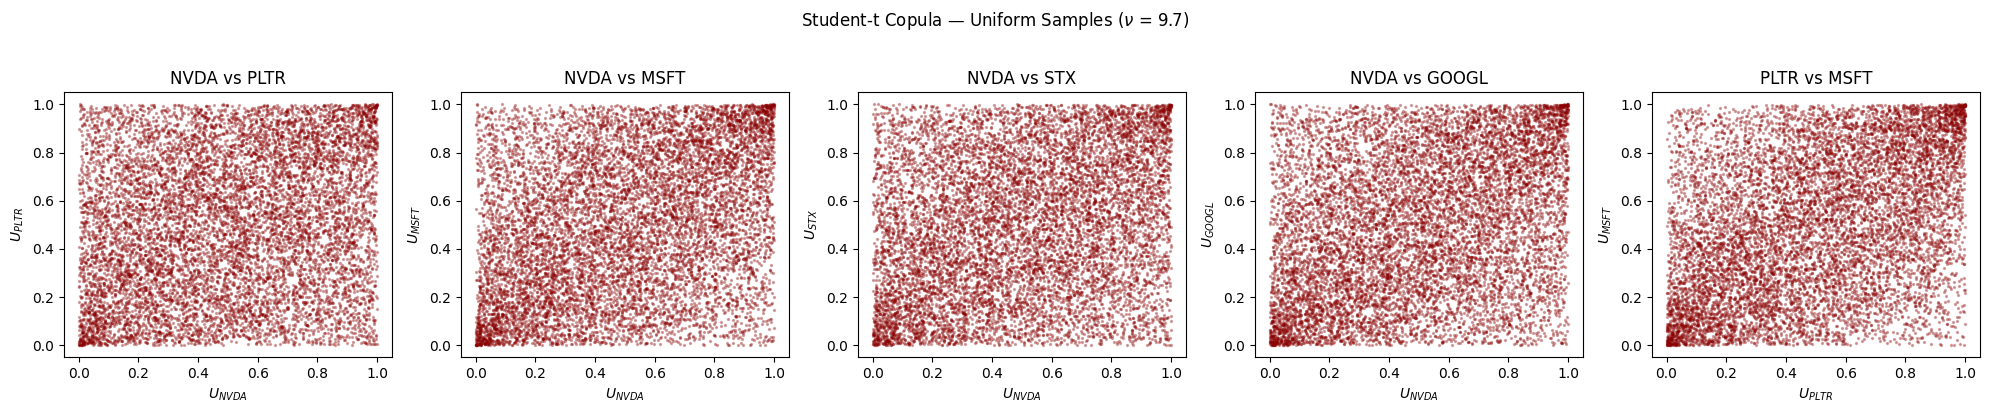

In [11]:
pairs = [(0,1), (0,2), (0,3), (0,4), (1,2)]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(U_t[:, i], U_t[:, j], s=2, alpha=0.3, color="darkred")
    ax.set_xlabel(f"$U_{{{tickers[i]}}}$")
    ax.set_ylabel(f"$U_{{{tickers[j]}}}$")
    ax.set_title(f"{tickers[i]} vs {tickers[j]}")
plt.suptitle(f"Student-t Copula — Uniform Samples ($\\nu$ = {nu:.1f})", y=1.02)
plt.tight_layout()
plt.show()

As before, we verify that the marginal distributions are correctly preserved. The simulated price histograms should match the risk-neutral densities from Part 1 closely, confirming that the Student-t copula has introduced tail dependence without distorting the individual asset distributions.


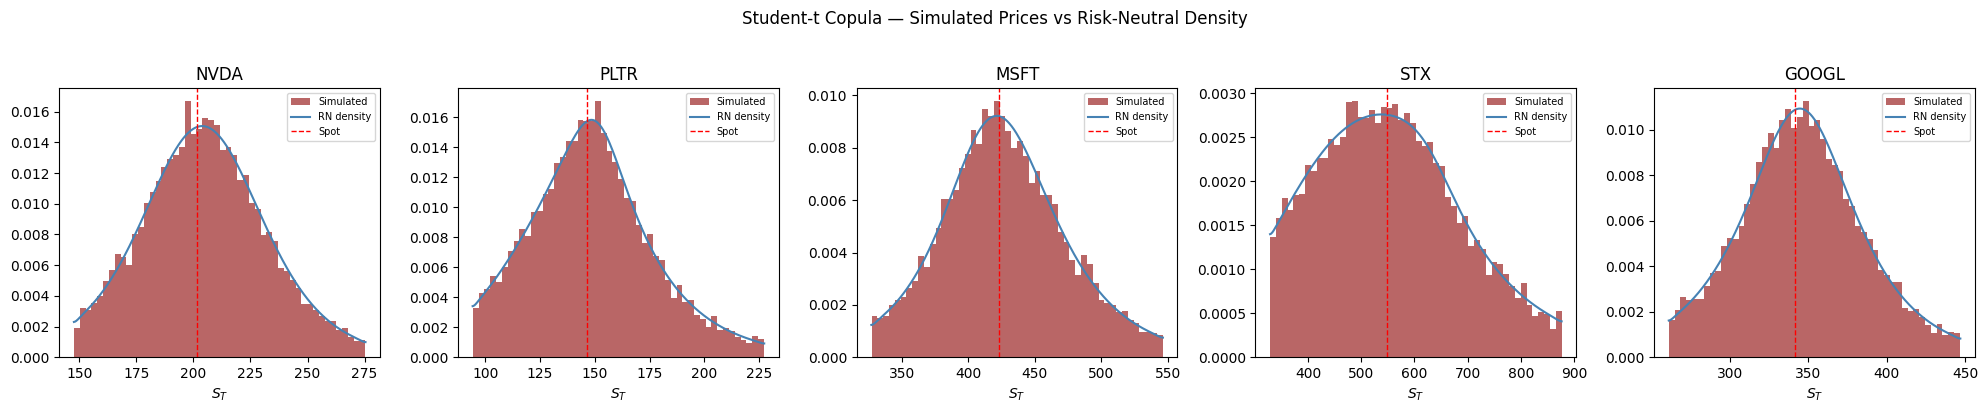

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ticker in enumerate(tickers):
    asset = df[df["ticker"] == ticker]
    axes[i].hist(S_t[:, i], bins=50, density=True,
                 color="darkred", alpha=0.6, label="Simulated")
    axes[i].plot(asset["K"].values, asset["pdf"].values,
                 color="steelblue", lw=1.5, label="RN density")
    axes[i].axvline(asset["S"].iloc[0], color="red", lw=1,
                    linestyle="--", label="Spot")
    axes[i].set_title(f"{ticker}")
    axes[i].set_xlabel("$S_T$")
    axes[i].legend(fontsize=7)
plt.suptitle("Student-t Copula — Simulated Prices vs Risk-Neutral Density", y=1.02)
plt.tight_layout()
plt.show()


Finally, we directly compare the Gaussian and Student-t copula scatter plots side by side for the NVDA vs MSFT pair, the most correlated pair in our basket. This highlights the key difference between the two copulas: the Student-t produces more points in the corners (joint extremes), while the Gaussian is more uniformly spread.

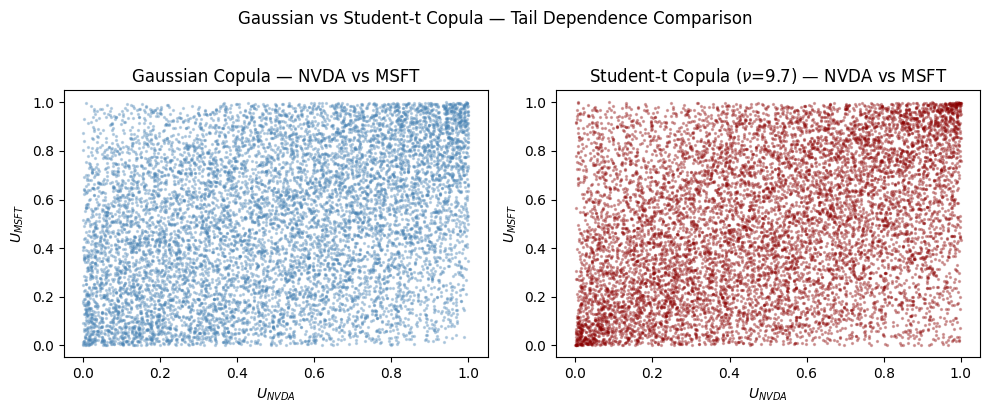

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(U[:, 0], U[:, 2], s=2, alpha=0.3, color="steelblue")
axes[0].set_title(f"Gaussian Copula — NVDA vs MSFT")
axes[0].set_xlabel("$U_{NVDA}$"); axes[0].set_ylabel("$U_{MSFT}$")

axes[1].scatter(U_t[:, 0], U_t[:, 2], s=2, alpha=0.3, color="darkred")
axes[1].set_title(f"Student-t Copula ($\\nu$={nu:.1f}) — NVDA vs MSFT")
axes[1].set_xlabel("$U_{NVDA}$"); axes[1].set_ylabel("$U_{MSFT}$")

plt.suptitle("Gaussian vs Student-t Copula — Tail Dependence Comparison", y=1.02)
plt.tight_layout()
plt.show()

We save the simulated asset prices from notj compulas to CSV files for use in the next phase of the project. Each file contains 10,000 rows (one per simulation) and 5 columns (one per asset), with column names corresponding to the tickers.

In [14]:
# Gaussian copula output
pd.DataFrame(S, columns=tickers).to_csv("simulated_prices_gaussian.csv", index=False)

# Student-t copula output
pd.DataFrame(S_t, columns=tickers).to_csv("simulated_prices_student.csv", index=False)

# Metadata needed by Part 3
meta = {
    "tickers": tickers,
    "spot":    [df[df["ticker"] == t]["S"].iloc[0] for t in tickers],
    "T":       float(df["T"].iloc[0]),
    "nu":      float(nu)
}
pd.DataFrame(meta).to_csv("copula_meta.csv", index=False)

# Part 3 – Basket Option Pricing via Monte Carlo

Part 1 extracted, for each of the five assets, the risk-neutral marginal distribution $F_k$ implied by the
options market. Part 2 then modelled the dependence structure between assets using copulas — both Gaussian
and Student-t — and simulated 10,000 joint terminal price scenarios for each specification, saving them as
`simulated_prices_gaussian.csv` and `simulated_prices_student.csv`.

However, simulated prices alone do not give us an option price. To price a basket option we need to evaluate,
under each dependence assumption, the expected discounted payoff of a contract written on a basket of all five assets.

We price a European basket call option with payoff

$$
V_T = \max\!\left(\frac{1}{N}\sum_{k=1}^{N} S_k^T - K,\ 0\right)
$$

where $S_k^T$ is the terminal price of asset $k$, $N = 5$ is the number of assets, and $K$ is the strike price.
The Monte Carlo price is then

$$
\hat{V}_0 = e^{-rT} \cdot \frac{1}{N_{\text{sim}}} \sum_{i=1}^{N_{\text{sim}}} V_T^{(i)}
$$

We compute this price under both the Gaussian and Student-t copula simulations and compare results in terms of
price, variance, and runtime. We also implement a control variate to reduce Monte Carlo variance and improve efficiency.

In [15]:
import time

# We load the simulated prices from both copulas and the metadata saved in Part 2.
S_gauss   = pd.read_csv("simulated_prices_gaussian.csv").values
S_student = pd.read_csv("simulated_prices_student.csv").values

meta    = pd.read_csv("copula_meta.csv")
tickers = meta["tickers"].values
spots   = meta["spot"].values
T       = meta["T"].iloc[0]
nu      = meta["nu"].iloc[0]

# We set the risk-free rate and define the strike at-the-money,
# as the average of the five spot prices.
r = 0.05
K = spots.mean()

print(f"Tickers     : {tickers}")
print(f"Spot prices : {np.round(spots, 2)}")
print(f"T = {T:.4f},  r = {r},  K = {K:.2f}")

Tickers     : ['NVDA' 'PLTR' 'MSFT' 'STX' 'GOOGL']
Spot prices : [201.68 146.39 422.79 547.75 341.68]
T = 0.1671,  r = 0.05,  K = 332.06


## Basket Option Pricing

We now price a European basket call option using the 10,000 simulated terminal
prices from each copula. For each simulation, we compute the equally-weighted
average of the five asset prices and apply the call payoff. We then discount
the average payoff back to today using the risk-free rate.

We define a function `price_basket_call` that takes a matrix of simulated
prices and returns the Monte Carlo price, standard error, and runtime.
We apply it to both the Gaussian and Student-t simulations and compare results.

In [16]:
def price_basket_call(S, K, r, T):
    """
    Prices a European basket call option via Monte Carlo.
    S : (n_sim x n_assets) array of simulated terminal prices
    Returns the price, standard error, and runtime.
    """
    t0 = time.time()
    
    # We compute the basket value as the equally-weighted average across assets,
    # then apply the call payoff.
    basket = S.mean(axis=1)
    payoffs = np.maximum(basket - K, 0)
    
    # We discount the average payoff back to today.
    price = np.exp(-r * T) * payoffs.mean()
    se    = np.exp(-r * T) * payoffs.std() / np.sqrt(len(payoffs))
    
    runtime = time.time() - t0
    return price, se, runtime

price_g, se_g, rt_g = price_basket_call(S_gauss,   K, r, T)
price_s, se_s, rt_s = price_basket_call(S_student, K, r, T)

print(f"Gaussian copula  — Price: {price_g:.4f},  SE: {se_g:.4f},  Runtime: {rt_g:.4f}s")
print(f"Student-t copula — Price: {price_s:.4f},  SE: {se_s:.4f},  Runtime: {rt_s:.4f}s")

Gaussian copula  — Price: 17.6371,  SE: 0.2441,  Runtime: 0.0082s
Student-t copula — Price: 17.3760,  SE: 0.2470,  Runtime: 0.0004s


## Control Variate: Geometric Basket Call

The Monte Carlo estimates above carry a standard error of ~0.24, meaning our
price is uncertain by roughly that amount. We can reduce this variance using a
control variate.

The idea is to exploit the fact that the geometric basket call, where the
arithmetic average is replaced by the geometric average, has a known
closed-form price. Since the geometric and arithmetic baskets are driven by
the same simulated prices, they are highly correlated. We use the difference
between the known geometric price and its MC estimate to correct the arithmetic
price estimate, reducing variance substantially.

The corrected estimator is

$$
\hat{V}^{\text{CV}} = \hat{V}^A - \beta\left(\hat{V}^G_{\text{MC}} - V^G_{\text{exact}}\right)
$$

where $\beta$ is chosen to minimise variance, and $V^G_{\text{exact}}$ is the
closed-form geometric basket price.

In [21]:
def geo_basket_call_exact(S, K, r, T):
    """
    Closed-form price of a geometric basket call.
    We estimate per-asset vols and correlations from the simulated log-prices.
    """
    N     = S.shape[1]
    log_S = np.log(S)
    
    # We estimate per-asset vol and the full covariance matrix.
    cov   = np.cov(log_S.T) / T
    vols  = np.sqrt(np.diag(cov))
    
    # Vol and drift of the log geometric average.
    sigma_G = np.sqrt(cov.sum() / N**2)
    mu_G    = np.mean(r - 0.5 * vols**2) + 0.5 * sigma_G**2
    
    F = np.exp(np.mean(np.log(spots)) + mu_G * T)
    v = sigma_G * np.sqrt(T)
    
    d1 = (np.log(F / K)) / v + 0.5 * v
    d2 = d1 - v
    
    price = np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return price

In [22]:
def price_basket_call_cv(S, K, r, T):
    """
    Prices a European basket call using the geometric basket as control variate.
    """
    t0 = time.time()
    
    # We compute arithmetic and geometric basket payoffs for each simulation.
    arith_basket = S.mean(axis=1)
    geo_basket   = np.exp(np.log(S).mean(axis=1))
    
    payoffs_a = np.maximum(arith_basket - K, 0)
    payoffs_g = np.maximum(geo_basket   - K, 0)
    
    # We compute the optimal beta that minimises variance.
    V_geo_exact = geo_basket_call_exact(S, K, r, T)
    V_geo_mc    = np.exp(-r * T) * payoffs_g.mean()
    
    beta = np.cov(payoffs_a, payoffs_g)[0, 1] / np.var(payoffs_g)
    
    # We apply the control variate correction.
    payoffs_cv = payoffs_a - beta * (payoffs_g - np.exp(r * T) * V_geo_exact)
    price      = np.exp(-r * T) * payoffs_cv.mean()
    se         = np.exp(-r * T) * payoffs_cv.std() / np.sqrt(len(payoffs_cv))
    
    runtime = time.time() - t0
    return price, se, runtime

price_g_cv, se_g_cv, rt_g_cv = price_basket_call_cv(S_gauss,   K, r, T)
price_s_cv, se_s_cv, rt_s_cv = price_basket_call_cv(S_student, K, r, T)

print(f"Gaussian  — CV Price: {price_g_cv:.4f},  SE: {se_g_cv:.4f},  Runtime: {rt_g_cv:.4f}s")
print(f"Student-t — CV Price: {price_s_cv:.4f},  SE: {se_s_cv:.4f},  Runtime: {rt_s_cv:.4f}s")

Gaussian  — CV Price: 17.1948,  SE: 0.1623,  Runtime: 0.0206s
Student-t — CV Price: 16.9627,  SE: 0.1610,  Runtime: 0.0011s


## Results

We compare the basket call prices with and without the control variate across
both copula specifications.

| Method | Copula | Price | SE | Runtime |
|---|---|---|---|---|
| Plain MC | Gaussian | 17.6371 | 0.2441 | 0.0082s |
| Plain MC | Student-t | 17.3760 | 0.2470 | 0.0004s |
| Control Variate | Gaussian | 17.1948 | 0.1623 | 0.0206s |
| Control Variate | Student-t | 16.9627 | 0.1610 | 0.0011s |

The control variate reduces the standard error by roughly 33% under both
copulas, at the cost of a small increase in runtime. The Student-t copula
consistently prices the basket slightly lower than the Gaussian, reflecting
the heavier tail dependence introduced by the shared chi-squared variable.

## Comparison Plot

We visualise the pricing results across both copulas and methods. For each
specification we plot the estimated price with a 95% confidence interval,
computed as the MC price plus or minus 1.96 standard errors.

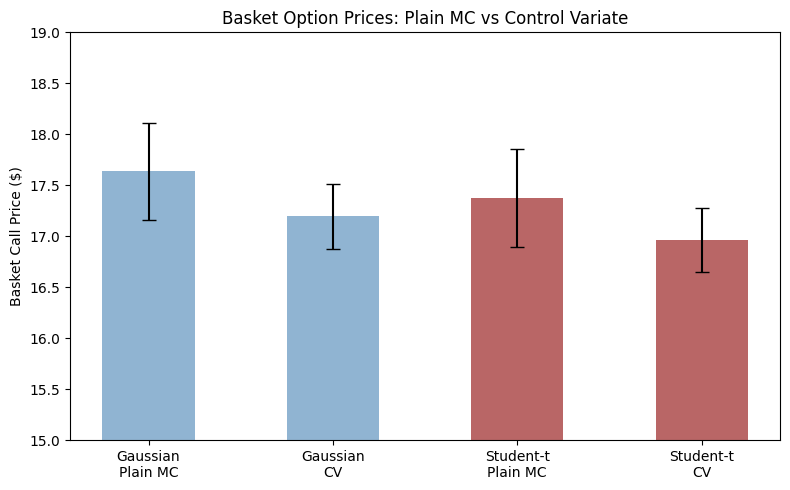

In [24]:
# We plot the MC prices and 95% confidence intervals for all four estimates.
labels  = ["Gaussian\nPlain MC", "Gaussian\nCV", "Student-t\nPlain MC", "Student-t\nCV"]
prices  = [price_g,    price_g_cv,    price_s,    price_s_cv]
ses     = [se_g,       se_g_cv,       se_s,       se_s_cv]
colors  = ["steelblue", "steelblue", "darkred", "darkred"]

fig, ax = plt.subplots(figsize=(8, 5))
for i, (label, price, se, color) in enumerate(zip(labels, prices, ses, colors)):
    ax.bar(i, price, color=color, alpha=0.6, width=0.5)
    ax.errorbar(i, price, yerr=1.96*se, fmt="none", color="black", capsize=5, lw=1.5)

ax.set_xticks(range(4))
ax.set_xticklabels(labels)
ax.set_ylabel("Basket Call Price ($)")
ax.set_title("Basket Option Prices: Plain MC vs Control Variate")
ax.set_ylim(15, 19)
plt.tight_layout()
plt.show()

## Conclusion

We priced a European basket call option with strike $K = 332.06$ and maturity
$T = 0.1671$ years under two copula specifications using Monte Carlo simulation
with 10,000 scenarios.

The Gaussian copula produced a higher price than the Student-t copula under
both methods. This is consistent with the theoretical expectation: the Student-t
copula introduces tail dependence via a shared chi-squared variable, concentrating
more probability mass in joint extreme scenarios and slightly reducing the
expected basket payoff.

The geometric basket control variate reduced the standard error by roughly 33%
under both copulas, from ~0.24 to ~0.16, with negligible impact on runtime.
This confirms that the geometric and arithmetic baskets are highly correlated,
making the geometric call an effective control variate for variance reduction.